In [ ]:
import os
%cd ~/erc-src/cuneiform-ocr/
os.getcwd()

%load_ext autoreload
%autoreload 2

import sys
import os

# Import broken sign filter and sign resolver
from data_processing.broken_sign_filter import filter_broken_from_text
from data_processing.sign_resolver import SignToABZResolver

# MongoDB URI for SignToABZResolver
MONGODB_URI = "YOUR_MONGODB_URI"  # Replace with your actual MongoDB URI

# Create global ABZ resolver
abz_resolver = SignToABZResolver(MONGODB_URI)
abz_resolver.connect()
print("ABZ resolver initialized and connected")

/dss/pn34bu-dss-0000/src/cuneiform-ocr
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ABZ resolver initialized and connected


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [14]:
# =============================================================================
# Configuration and Setup
# =============================================================================
# Note: Ground truth processing now includes (same as evaluate_signs_detection.py):
# 1. Filter broken signs using filter_broken_from_text
# 2. Convert sign names to ABZ format using SignToABZResolver
# Detected signs from the model are already in ABZ format

API_URL = "https://ebl.badw.de/api/fragments/"
available_fragments = [ # some fragments from training set, for quick testing
    "YBC.5721",
    "IM.136906",
    "YBC.5750",
    "MLC.32",
    "HS.1015",
    "CBS.1498",
    "U.30627",
    "BM.40295",
    "HS.156",
    "YBC.5711",
    "HS.1023",
    "K.10211",
    "HS.2042",
    "BM.38432",
    "IM.136590",
    "HS.367"
]
thresholds = [0.05 * i for i in range(1, 20)]
print("thresholds: ", thresholds)
y_thresholds = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]  # Grid search for y_threshold
print("y_thresholds: ", y_thresholds)
print("len of available fragments:", len(available_fragments))
classes = ['ABZ58', 'ABZ441', 'ABZ207', 'ABZ55', 'ABZ139', 'ABZ597', 'ABZ343', 'ABZ142', 'ABZ73', 'ABZ59', 'ABZ586', 'ABZ579', 'ABZ457', 'ABZ427', 'ABZ86', 'ABZ212', 'ABZ5', 'ABZ537', 'ABZ376', 'ABZ335', 'ABZ170', 'ABZ342', 'ABZ324', 'ABZ480', 'ABZ61', 'ABZ206', 'ABZ545', 'ABZ99', 'ABZ72', 'ABZ112', 'ABZ142a', 'ABZ396', 'ABZ103', 'ABZ13', 'ABZ70', 'ABZ69', 'ABZ437', 'ABZ381', 'X', 'ABZ279', 'ABZ52', 'ABZ128', 'ABZ97', 'ABZ151', 'ABZ465', 'ABZ461', 'ABZ595', 'ABZ468', 'ABZ1', 'ABZ449', 'ABZ318', 'ABZ384', 'ABZ214', 'ABZ111', 'ABZ367', 'ABZ84', 'ABZ319', 'ABZ62', 'ABZ314', 'ABZ556', 'ABZ7', 'ABZ230', 'ABZ74', 'ABZ144', 'ABZ331', 'ABZ330', 'ABZ598a', 'ABZ575', 'ABZ322', 'NoABZ0', 'ABZ6', 'ABZ354', 'ABZ172', 'ABZ399', 'ABZ328', 'ABZ471', 'ABZ332', 'ABZ593', 'ABZ233', 'ABZ148', 'ABZ538', 'ABZ12', 'ABZ57', 'ABZ481', 'ABZ313', 'ABZ167', 'ABZ15', 'ABZ68', 'ABZ353', 'ABZ398', 'ABZ532', 'ABZ371', 'ABZ231', 'ABZ80', 'ABZ314', 'ABZ295', 'ABZ115', 'ABZ411', 'ABZ308', 'ABZ191', 'ABZ296', 'ABZ412', 'ABZ565', 'ABZ401', 'ABZ589', 'ABZ211', 'ABZ472', 'ABZ570', 'ABZ79', 'ABZ75', 'ABZ298', 'ABZ420', 'ABZ535', 'ABZ134', 'ABZ536', 'ABZ101', 'ABZ533', 'ABZ536', 'ABZ126', 'ABZ94', 'ABZ9', 'ABZ232', 'ABZ393', 'ABZ60', 'ABZ104', 'ABZ131', 'ABZ306', 'ABZ38', 'ABZ470', 'ABZ557', 'ABZ333', 'NoABZ0', 'ABZ147', 'ABZ145', 'ABZ56', 'ABZ564', 'ABZ383', 'ABZ360', 'ABZ114', 'ABZ138', 'ABZ331e+152i', 'ABZ297', 'ABZ334', 'ABZ366', 'ABZ50', 'ABZ455', 'ABZ598b', 'ABZ339', 'ABZ205', 'ABZ78', 'ABZ87', 'ABZ554', 'ABZ85', 'ABZ536', 'ABZ312', 'ABZ69', 'ABZ433', 'ABZ124', 'ABZ164', 'ABZ129a', 'NoABZ0', 'ABZ76', 'ABZ326', 'ABZ143', 'ABZ440', 'ABZ559', 'ABZ307', 'ABZ374', 'ABZ74', 'ABZ451', 'ABZ574', 'NoABZ0', 'ABZ529']

thresholds:  [0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5, 0.55, 0.6000000000000001, 0.65, 0.7000000000000001, 0.75, 0.8, 0.8500000000000001, 0.9, 0.9500000000000001]
y_thresholds:  [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
len of available fragments: 16


In [15]:
# 2. request fragment signs from EBL API (with broken sign filtering and ABZ conversion)
import requests
def fetch_fragment_signs(fragment_id) -> tuple[str, dict]:
    """
    Get fragment signs field with broken sign filtering and ABZ conversion
    return str(signs in ABZ format), dict(full fragment data)
    """
    response = requests.get(f"{API_URL}{fragment_id}")
    response.raise_for_status()
    fragment_data = response.json()
    
    # Get text data and apply broken sign filter
    text_data = fragment_data.get('text')
    if text_data:
        # Use broken_sign_filter to extract signs (with filtering)
        lines = filter_broken_from_text(text_data)
        
        if lines:
            # Convert to space-separated string format (sign names)
            signs_text = ' '.join(' '.join(line) for line in lines)
            
            # Convert sign names to ABZ format
            abz_text = abz_resolver.convert_signs_to_abz(signs_text)
            
            return abz_text, fragment_data
    
    # Fallback: return the original signs field if text processing fails
    return fragment_data.get("signs", ""), fragment_data

In [24]:
# 3. Query database and select valid fragments
from pymongo import MongoClient
import gridfs
import random

# Connect to MongoDB
client = MongoClient(MONGODB_URI)
db = client['ebl']
files_collection = db['photos.files']
fs = gridfs.GridFS(db, collection='photos')

# Get all photos from database
cursor = files_collection.find({})
all_photos = list(cursor)
photo_count = len(all_photos)
print(f"Total photos in database: {photo_count}")

# Shuffle photos for random sampling
random.shuffle(all_photos)

# Select particular number of valid fragments
selected_fragments = []
target_count = 30

for photo in all_photos:
    if len(selected_fragments) >= target_count:
        break
    
    filename = photo.get('filename', '')
    # Remove file extension to get fragment_id
    fragment_id = filename.rsplit('.', 1)[0] if '.' in filename else filename
    
    try:
        # Fetch signs from API
        signs, _ = fetch_fragment_signs(fragment_id)
        
        # Check if signs string is non-empty
        if signs and signs.strip():
            selected_fragments.append(fragment_id)
            print(f"Selected {len(selected_fragments)}/{target_count}: {fragment_id}")
        else:
            print(f"Skipping {fragment_id}: empty signs")
    except Exception as e:
        print(f"Skipping {fragment_id}: {e}")
        continue

print(f"\nFinally selected {len(selected_fragments)} fragments:")
print(selected_fragments)

Total photos in database: 92219
Selected 1/30: K.6258
Skipping MLC.296: empty signs
Skipping BM.48810: empty signs
Skipping YBC.15910: empty signs
Skipping BM.40776: empty signs
Selected 2/30: K.21001
Selected 3/30: YBC.7464
Selected 4/30: Rm.222
Skipping BM.36900: empty signs
Skipping K.5079: empty signs
Selected 5/30: K.23275
Selected 6/30: GCBC.553
Skipping NBC.4099: empty signs
Skipping YBC.14666: empty signs
Skipping K.18330: empty signs
Selected 7/30: K.16164
Skipping RBC.339: empty signs
Selected 8/30: HS.1226
Selected 9/30: BM.35350
Skipping K.2455: empty signs
Skipping K.22890: empty signs
Skipping YBC.14359: empty signs
Skipping YBC.9206: empty signs
Skipping NBC.5418: empty signs
Selected 10/30: 2023,6003.125
Skipping BM.46240: empty signs
Skipping K.10473: empty signs
Skipping K.7622: empty signs
Selected 11/30: YBC.7499
Selected 12/30: K.18511
Skipping BM.52079: empty signs
Skipping RBC.45: empty signs
Skipping YBC.11241: empty signs
Skipping BM.51975: empty signs
Skipping

In [25]:
# 4. detect signs from image
from io import BytesIO
import shutil
from PIL import Image
import os
import torch.nn as nn
from mmdet.apis import init_detector, inference_detector
import mmcv

test_img_dir = "./imgs"

def fetch_image_from_db(fragment_id):
    """Fetch image from MongoDB GridFS by fragment_id."""
    try:
        # Attempt to find the file in GridFS
        grid_out = fs.find_one({'filename': f"{fragment_id}.jpg"})
        if grid_out is None:
            print(f"Image for fragment_id {fragment_id} not found in database.")
            return None
        
        # Read the image data
        image_data = grid_out.read()
        image = Image.open(BytesIO(image_data))
        return image
    except Exception as e:
        print(f"Error fetching image for fragment_id {fragment_id}: {e}")
        return None

def pre_download_images(fragment_ids, test_img_dir="./imgs/predownloaded"):
    # remove and recreate test_img_dir
    shutil.rmtree(test_img_dir, ignore_errors=True)
    os.makedirs(test_img_dir, exist_ok=True)
    for fragment_id in fragment_ids:
        image = fetch_image_from_db(fragment_id)
        if image:
            filename = f"{fragment_id}.jpg"
            image.save(os.path.join(test_img_dir, filename))
            print(f"Downloaded and saved image for fragment_id {fragment_id} as {filename}")
        else:
            print(f"Failed to download image for fragment_id {fragment_id}")

def get_fragment_image(fragment_id, fetch_approach="dir", img_dir="~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/imgs"):
    # got image from API
    image = None
    if fetch_approach == "api":
        response = requests.get(f"{API_URL}{fragment_id}/photo")
        # display image
        image = Image.open(BytesIO(response.content))
    elif fetch_approach == "db":
        image = fetch_image_from_db(fragment_id)
        filename = fragment_id + ".jpg"
        image.save(f"{filename}")
        image = mmcv.imread(f"{filename}")
        os.remove(f"{filename}")
    else:
        # look for image in img_dir with name fragment_id.jpg
        img_path = os.path.join(os.path.expanduser(img_dir), f"{fragment_id}.jpg")
        if not os.path.exists(img_path):
            img_path = os.path.join(os.path.expanduser(test_img_dir), f"{fragment_id}.jpg")
            if not os.path.exists(img_path):
                return None
        # image = Image.open(img_path)
        image = mmcv.imread(img_path)
        
    return image

def get_detected_signs(image, threshold, y_threshold, model: nn.Module) -> str:
    """get detected signs from your detection model"""
    if image is None:
        return ""  
    inference_result = inference_detector(model, image)
    OCR_result = inference_result.pred_instances.cpu()
    labels, bboxes = OCR_result['labels'], OCR_result['bboxes']
    certain_scores_idx = len(OCR_result['scores'][OCR_result['scores'] > threshold])
    certain_bboxes = bboxes[:certain_scores_idx]
    labels = OCR_result['labels'][:certain_scores_idx]
    indexed_bounding_boxes = list(enumerate(certain_bboxes))
    sorted_indexed_bounding_boxes = sorted(indexed_bounding_boxes, key=lambda item: (item[1][1], item[1][0]))

    lines = []
    current_line = []
    # y_threshold = 50

    for i, (index, box) in enumerate(sorted_indexed_bounding_boxes):
        if not current_line:
            current_line.append((index, box))
        else:
            prev_box = current_line[-1][1]
            if box[1] - prev_box[1] < y_threshold:
                current_line.append((index, box))
            else:
                lines.append(current_line)
                current_line = [(index, box)]
    if current_line:
        lines.append(current_line)

    sorted_lines = [sorted(line, key=lambda item: item[1][0]) for line in lines]

    result = ""
    bounding_boxes = []
    for line in sorted_lines:
        for index, box in line:
            if classes[labels[index]] == 'NoABZ0':
                result += 'X '
            else:
                result += classes[labels[index]] + ' '
            bounding_boxes.append(box.tolist())  # Convert tensor to list for easier handling
        result += '\n'

    return result

In [26]:
# Custom FragmentModel with overlap information
from ebl_ngrams import FragmentModel
from typing import Union, Tuple
import pandas as pd

class FragmentModelWithOverlaps(FragmentModel):
    """
    Extended FragmentModel that can return overlap information alongside match scores.
    """
    
    def match_with_overlaps(
        self, 
        other: FragmentModel, 
        *n_values, 
        length_weighting=False
    ) -> Tuple[float, dict]:
        """
        Calculate match score and return overlap information.
        
        Args:
            other: Another FragmentModel to compare against
            *n_values: N-gram sizes to consider
            length_weighting: Whether to apply length weighting
            
        Returns:
            Tuple of (score, overlap_info) where overlap_info contains:
                - 'overlap': set of overlapping n-grams
                - 'overlap_size': number of overlapping n-grams
        """
        # Get intersection
        intersection = self.intersection(other, *n_values)
        
        # Calculate match score (same as original)
        from ebl_ngrams.metrics import no_weight, weight_by_len
        weighted_sum = weight_by_len if length_weighting else no_weight
        
        intersection_size = weighted_sum(intersection)
        self_size = weighted_sum(self.get_ngrams(*n_values))
        other_size = weighted_sum(other.get_ngrams(*n_values))
        
        score = (
            intersection_size / min(self_size, other_size)
            if self_size and other_size
            else 0.0
        )
        
        # Prepare overlap information
        overlap_info = {
            'overlap': intersection,
            'overlap_size': len(intersection)
        }
        
        return score, overlap_info
    
    def match(
        self, 
        other: FragmentModel, 
        *n_values, 
        length_weighting=False,
        include_overlaps=False
    ) -> Union[float, Tuple[float, dict]]:
        """
        Calculate match score with optional overlap information.
        
        Args:
            other: Another FragmentModel to compare against
            *n_values: N-gram sizes to consider
            length_weighting: Whether to apply length weighting
            include_overlaps: If True, return (score, overlap_info) tuple
            
        Returns:
            float: match score (if include_overlaps=False)
            Tuple[float, dict]: (score, overlap_info) (if include_overlaps=True)
        """
        if include_overlaps:
            return self.match_with_overlaps(other, *n_values, length_weighting=length_weighting)
        else:
            # Use original match method
            return super().match(other, *n_values, length_weighting=length_weighting)

In [27]:
# 3 & 4. calculate match score for a single fragment
# from ebl_ngrams import FragmentModel
from data_processing.divide_photos import divide_tablet_photo

def calculate_match_score(fragment_id, threshold, y_threshold, model: nn.Module, debug=False, visualizer=None, predownloaded_dir=None) -> float:
    ground_truth_signs, _ = fetch_fragment_signs(fragment_id)
    fetch_approach = "dir" if predownloaded_dir else "db"
    image = get_fragment_image(fragment_id, fetch_approach=fetch_approach, img_dir=predownloaded_dir)

    detected_signs = ""
    cropped_images = divide_tablet_photo(image, visualize=False, logging=False)
    for img in cropped_images:
        detected_signs_of_one_cropped = get_detected_signs(img, threshold, y_threshold, model)
        detected_signs += detected_signs_of_one_cropped
    
    if debug:
        for i, img in enumerate(cropped_images):
            print(f"Fragment {i + 1}: {img.shape}")
            print(f"data type: {img.dtype}")

    if not ground_truth_signs.strip():
        print(f"Warning: No ground truth signs for fragment {fragment_id}")
        return 0.0
    
    ground_truth_doc = FragmentModelWithOverlaps(
        id_=f"{fragment_id}_gt",
        signs=ground_truth_signs,
    )
    ground_truth_doc.set_ngrams()

    detected_doc = FragmentModelWithOverlaps(
        id_=f"{fragment_id}_detected",
        signs=detected_signs,
    )
    detected_doc.set_ngrams()

    score, overlap_info = detected_doc.match(ground_truth_doc, include_overlaps=True)
    score2, overlap_info2 = ground_truth_doc.match(detected_doc, include_overlaps=True)
    if score - score2 > 1e-6:
        raise ValueError("scores detected from two directions do not match")

    if overlap_info['overlap_size'] != overlap_info2['overlap_size']:
        raise ValueError("overlap sizes detected from two directions do not match")
    
    if debug and visualizer is not None:
        print("signs detected: ", detected_signs)
    #     vis_image = visualizer.add_datasample(
    #         'result',
    #         image,
    #         data_sample=result,
    #         draw_gt=False,
    #         wait_time=0,
    #     )
    #     # show image in scale factor of 0.3
    #     vis_image = mmcv.imresize(vis_image, scale=0.3)
    #     mmcv.imshow(vis_image)

    return score, overlap_info['overlap_size']



In [28]:
# 5 & 6. calculate average scores for each threshold and y_threshold combination
def evaluate_thresholds_2d(fragment_urls, thresholds, y_thresholds, model: nn.Module):
    pre_download_dir = "./imgs/predownloaded"
    pre_download_images(fragment_urls, test_img_dir=pre_download_dir)

    results = {}
    for y_threshold in y_thresholds:
        for threshold in thresholds:
            print(f"evaluating threshold = {threshold}, y_threshold = {y_threshold}...")
            scores = []
            overlaps = []

            for fragment_id in fragment_urls:
                try:
                    print(f"  processing {fragment_id}", end="\t")
                    score, overlap = calculate_match_score(fragment_id, threshold, y_threshold, model, predownloaded_dir=pre_download_dir)
                    scores.append(score)
                    overlaps.append(overlap)
                    print(f"score: {score:.4f}, overlap: {overlap}")
                except Exception as e:
                    print(f"  {fragment_id}: error - {e}")
                    pass

            # calculate average score
            avg_score = sum(scores) / len(scores) if scores else 0.0
            avg_overlap = sum(overlaps) / len(overlaps) if overlaps else 0.0
            results[(threshold, y_threshold)] = {
                'average_score': avg_score,
                'average_overlap': avg_overlap,
                'individual_scores': scores,
                'individual_overlaps': overlaps,
                'count': len(scores)
            }
    return results

In [21]:
# load detection model
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
from mmdet.registry import VISUALIZERS
import mmcv
config_file = 'configs/detr.py'
checkpoint_file = '~/erc-work-data/retrained_models/detr-173/epoch_1000.pth'
register_all_modules()
model = init_detector(config_file, checkpoint_file, device='cuda:0')

visualizer = VISUALIZERS.build(model.cfg.visualizer)
visualizer.dataset_meta = model.dataset_meta

Loads checkpoint by local backend from path: ~/erc-work-data/retrained_models/detr-173/epoch_1000.pth


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


In [29]:
# test inference
# test_fragment_id = available_fragments[0]   
test_fragment_id = "K.3301"
y_threshold = 30
score, overlap = calculate_match_score(test_fragment_id, threshold=0.5, y_threshold=y_threshold, model=model,debug=True, visualizer=visualizer)
print(f"Test fragment {test_fragment_id} score at threshold 0.5: {score:.4f}, overlap: {overlap}")
score, overlap = calculate_match_score(test_fragment_id, threshold=0.9, y_threshold=y_threshold, model=model,debug=True, visualizer=visualizer)
print(f"Test fragment {test_fragment_id} score at threshold 0.9: {score:.4f}, overlap: {overlap}")
score, overlap = calculate_match_score(test_fragment_id, threshold=0.1, y_threshold=y_threshold, model=model,debug=True, visualizer=visualizer)
print(f"Test fragment {test_fragment_id} score at threshold 0.1: {score:.4f}, overlap: {overlap}")


Fragment 1: (1218, 1851, 3)
data type: uint8
Fragment 2: (2218, 1353, 3)
data type: uint8
Fragment 3: (1214, 502, 3)
data type: uint8
Fragment 4: (470, 607, 3)
data type: uint8
signs detected:  ABZ13 ABZ570 ABZ104 ABZ70 
ABZ536 ABZ480 ABZ13 ABZ579 
ABZ308 ABZ172 X ABZ233 ABZ231 
ABZ579 ABZ366 ABZ7 ABZ575 ABZ68 
ABZ579 ABZ383 ABZ381 ABZ61 
ABZ570 ABZ579 ABZ61 
ABZ80 X ABZ342 ABZ597 
ABZ295 ABZ172 X ABZ13 
ABZ308 X ABZ13 
ABZ172 X ABZ13 
ABZ308 ABZ172 X ABZ13 ABZ13 ABZ319 
ABZ172 X ABZ13 X 
X X ABZ411 ABZ13 
ABZ85 ABZ231 
ABZ579 ABZ70 ABZ461 ABZ461 
X 
X 
X X X 
ABZ5 ABZ313 
ABZ480 ABZ381 ABZ94 
ABZ214 
ABZ1 ABZ142 ABZ139 ABZ13 ABZ231 ABZ597 
ABZ366 ABZ5 
ABZ124 ABZ86 ABZ545 
X ABZ1 X ABZ5 
ABZ1 ABZ86 ABZ15 ABZ5 ABZ73 X 

Test fragment K.3301 score at threshold 0.5: 0.2291, overlap: 41
Fragment 1: (1218, 1851, 3)
data type: uint8
Fragment 2: (2218, 1353, 3)
data type: uint8
Fragment 3: (1214, 502, 3)
data type: uint8
Fragment 4: (470, 607, 3)
data type: uint8
signs detected:  ABZ13 
ABZ1

In [30]:
# run evaluation

import pandas as pd
results = evaluate_thresholds_2d(selected_fragments, thresholds, y_thresholds, model)

# create detailed results DataFrame showing each fragment's score and overlap at each threshold combination
data = []
for (threshold, y_threshold), result in results.items():
    for fragment_id, score, overlap in zip(selected_fragments, result['individual_scores'], result['individual_overlaps']):
        data.append({
            'Fragment': fragment_id,
            'Threshold': threshold,
            'Y_Threshold': y_threshold,
            'Score': score,
            'Overlap': overlap
        })

df_detailed = pd.DataFrame(data)

# create average scores and overlaps for each (threshold, y_threshold) combination
avg_data = []
for (threshold, y_threshold), result in results.items():
    avg_data.append({
        'Threshold': threshold,
        'Y_Threshold': y_threshold,
        'Avg_Score': result['average_score'],
        'Avg_Overlap': result['average_overlap']
    })

df_avg = pd.DataFrame(avg_data)

# pivot table for scores: rows = y_threshold, columns = threshold
df_pivot_score = df_avg.pivot(index='Y_Threshold', columns='Threshold', values='Avg_Score')

# pivot table for overlaps: rows = y_threshold, columns = threshold
df_pivot_overlap = df_avg.pivot(index='Y_Threshold', columns='Threshold', values='Avg_Overlap')

print("=" * 80)
print("Grid Search Results: Average Scores (rows=Y_Threshold, cols=Threshold)")
print("=" * 80)
print(df_pivot_score.to_string())
print("\n" + "=" * 80)

print("Grid Search Results: Average Overlaps (rows=Y_Threshold, cols=Threshold)")
print("=" * 80)
print(df_pivot_overlap.to_string())
print("\n" + "=" * 80)

# find the best parameter combination
best_idx = df_avg['Avg_Score'].idxmax()
best_params = df_avg.loc[best_idx]
print(f"Best Parameters:")
print(f"  Threshold: {best_params['Threshold']}")
print(f"  Y_Threshold: {best_params['Y_Threshold']}")
print(f"  Average Score: {best_params['Avg_Score']:.4f}")
print(f"  Average Overlap: {best_params['Avg_Overlap']:.2f}")
print("=" * 80)

Downloaded and saved image for fragment_id K.6258 as K.6258.jpg
Downloaded and saved image for fragment_id K.21001 as K.21001.jpg
Downloaded and saved image for fragment_id YBC.7464 as YBC.7464.jpg
Downloaded and saved image for fragment_id Rm.222 as Rm.222.jpg
Downloaded and saved image for fragment_id K.23275 as K.23275.jpg
Downloaded and saved image for fragment_id GCBC.553 as GCBC.553.jpg
Downloaded and saved image for fragment_id K.16164 as K.16164.jpg
Downloaded and saved image for fragment_id HS.1226 as HS.1226.jpg
Downloaded and saved image for fragment_id BM.35350 as BM.35350.jpg
Downloaded and saved image for fragment_id 2023,6003.125 as 2023,6003.125.jpg
Downloaded and saved image for fragment_id YBC.7499 as YBC.7499.jpg
Downloaded and saved image for fragment_id K.18511 as K.18511.jpg
Downloaded and saved image for fragment_id K.18367 as K.18367.jpg
Downloaded and saved image for fragment_id NBC.383 as NBC.383.jpg
Downloaded and saved image for fragment_id BM.40051 as BM.40

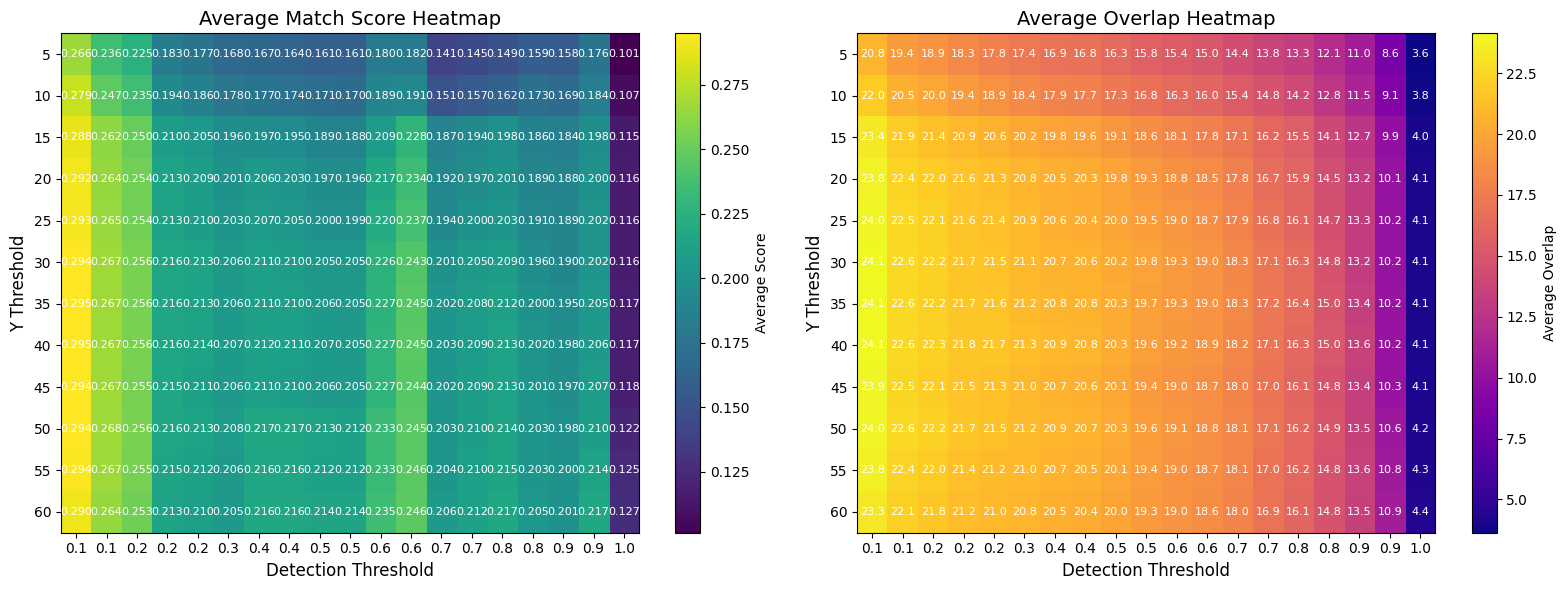

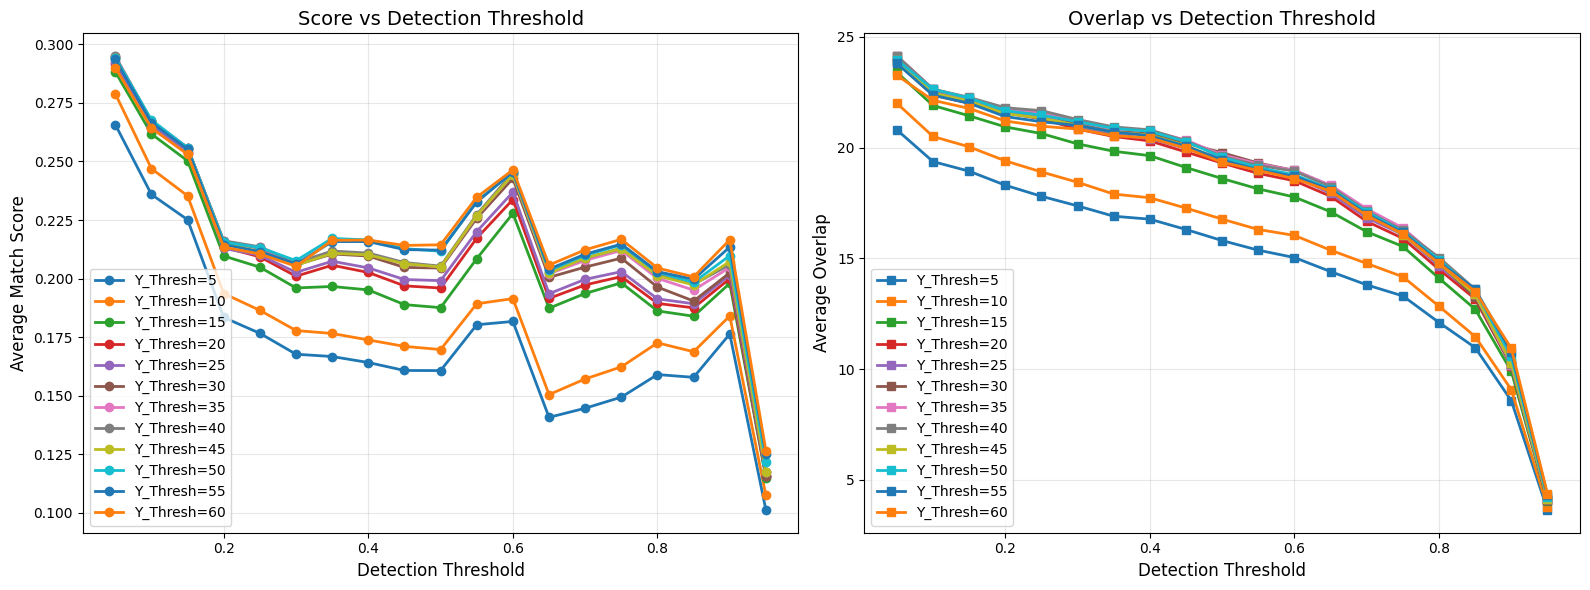

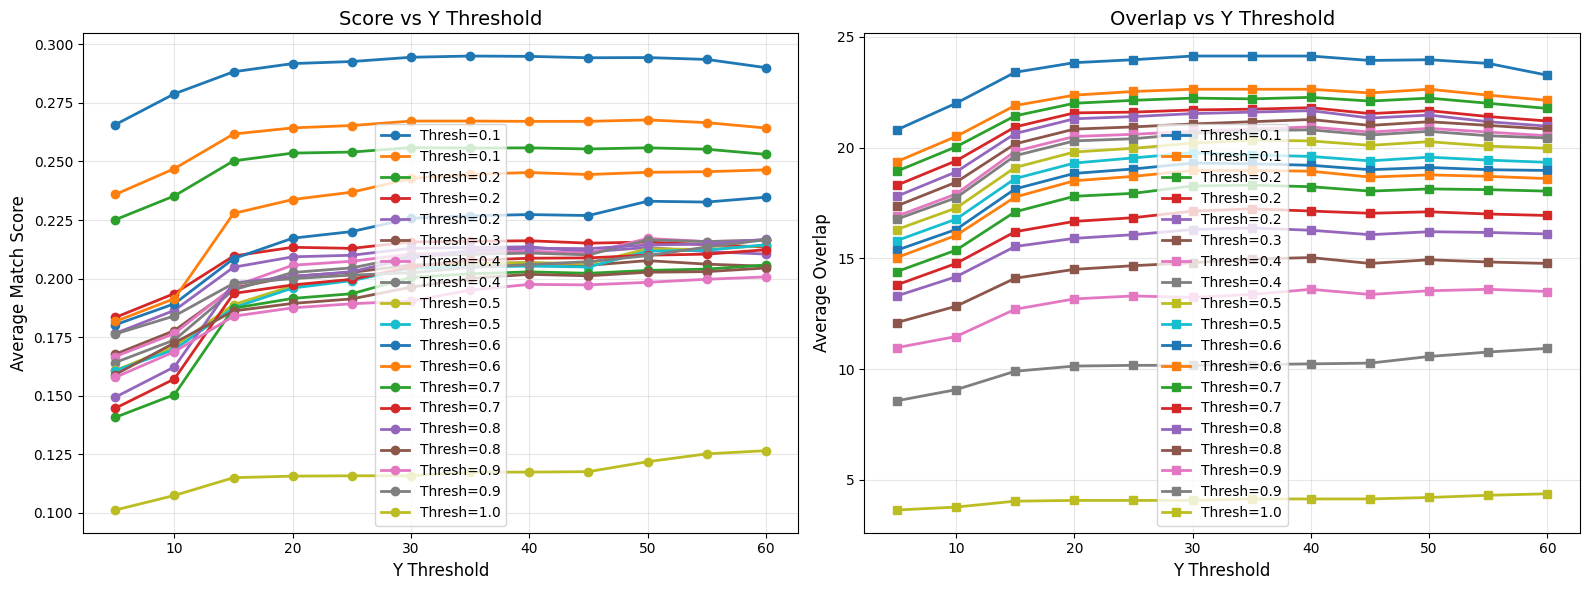

In [31]:
# visualize results (optional)
import matplotlib.pyplot as plt
import numpy as np

# 1. Heatmap for average scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap for scores
score_matrix = df_pivot_score.values
im1 = ax1.imshow(score_matrix, cmap='viridis', aspect='auto')
ax1.set_xticks(np.arange(len(thresholds)))
ax1.set_yticks(np.arange(len(y_thresholds)))
ax1.set_xticklabels([f'{t:.1f}' for t in thresholds])
ax1.set_yticklabels([f'{yt}' for yt in y_thresholds])
ax1.set_xlabel('Detection Threshold', fontsize=12)
ax1.set_ylabel('Y Threshold', fontsize=12)
ax1.set_title('Average Match Score Heatmap', fontsize=14)

# Add text annotations
for i in range(len(y_thresholds)):
    for j in range(len(thresholds)):
        text = ax1.text(j, i, f'{score_matrix[i, j]:.3f}',
                       ha="center", va="center", color="w", fontsize=8)

plt.colorbar(im1, ax=ax1, label='Average Score')

# Heatmap for overlaps
overlap_matrix = df_pivot_overlap.values
im2 = ax2.imshow(overlap_matrix, cmap='plasma', aspect='auto')
ax2.set_xticks(np.arange(len(thresholds)))
ax2.set_yticks(np.arange(len(y_thresholds)))
ax2.set_xticklabels([f'{t:.1f}' for t in thresholds])
ax2.set_yticklabels([f'{yt}' for yt in y_thresholds])
ax2.set_xlabel('Detection Threshold', fontsize=12)
ax2.set_ylabel('Y Threshold', fontsize=12)
ax2.set_title('Average Overlap Heatmap', fontsize=14)

# Add text annotations
for i in range(len(y_thresholds)):
    for j in range(len(thresholds)):
        text = ax2.text(j, i, f'{overlap_matrix[i, j]:.1f}',
                       ha="center", va="center", color="w", fontsize=8)

plt.colorbar(im2, ax=ax2, label='Average Overlap')

plt.tight_layout()
plt.show()

# 2. Line plots: Score vs Threshold for different Y_Thresholds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for y_thresh in y_thresholds:
    scores_for_y = df_avg[df_avg['Y_Threshold'] == y_thresh]['Avg_Score'].values
    overlaps_for_y = df_avg[df_avg['Y_Threshold'] == y_thresh]['Avg_Overlap'].values
    
    ax1.plot(thresholds, scores_for_y, marker='o', linewidth=2, markersize=6, label=f'Y_Thresh={y_thresh}')
    ax2.plot(thresholds, overlaps_for_y, marker='s', linewidth=2, markersize=6, label=f'Y_Thresh={y_thresh}')

ax1.set_xlabel('Detection Threshold', fontsize=12)
ax1.set_ylabel('Average Match Score', fontsize=12)
ax1.set_title('Score vs Detection Threshold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Detection Threshold', fontsize=12)
ax2.set_ylabel('Average Overlap', fontsize=12)
ax2.set_title('Overlap vs Detection Threshold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Line plots: Score vs Y_Threshold for different Thresholds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for thresh in thresholds:
    scores_for_thresh = df_avg[df_avg['Threshold'] == thresh]['Avg_Score'].values
    overlaps_for_thresh = df_avg[df_avg['Threshold'] == thresh]['Avg_Overlap'].values
    
    ax1.plot(y_thresholds, scores_for_thresh, marker='o', linewidth=2, markersize=6, label=f'Thresh={thresh:.1f}')
    ax2.plot(y_thresholds, overlaps_for_thresh, marker='s', linewidth=2, markersize=6, label=f'Thresh={thresh:.1f}')

ax1.set_xlabel('Y Threshold', fontsize=12)
ax1.set_ylabel('Average Match Score', fontsize=12)
ax1.set_title('Score vs Y Threshold', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Y Threshold', fontsize=12)
ax2.set_ylabel('Average Overlap', fontsize=12)
ax2.set_title('Overlap vs Y Threshold', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# Clean up: Close ABZ resolver connection
# Run this when you're done with all evaluations
if 'abz_resolver' in globals():
    cache_stats = abz_resolver.get_cache_stats()
    print(f"ABZ Resolver Cache Stats:")
    print(f"  Cached signs: {cache_stats['cached_signs']}")
    print(f"  Found in DB: {cache_stats['found']}")
    print(f"  Not found: {cache_stats['not_found']}")
    
    abz_resolver.close()
    print("\nABZ resolver connection closed")

ABZ Resolver Cache Stats:
  Cached signs: 903
  Found in DB: 373
  Not found: 530

ABZ resolver connection closed
